In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Amazon_Sale_Report_cleaned.csv")
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,Easy Ship
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship


In [3]:
#descriptive statistics
df[["Qty", "Amount"]].describe()

,Qty,Amount
count,128975.000000,128975.000000
mean,0.904431,645.928694
std,0.313354,272.778829
min,0.000000,0.000000
25%,1.000000,459.000000
50%,1.000000,605.000000
75%,1.000000,771.000000
max,15.000000,5584.000000


In [4]:
#calculating
print("Mean:", df["Amount"].mean())
print("Median:", df["Amount"].median())
print("Mode:", df["Amount"].mode()[0])
print("Standard Deviation:", df["Amount"].std())
print("Variance:", df["Amount"].var())

Mean: 645.9286939329328
Median: 605.0
Mode: 605.0
Standard Deviation: 272.77882866610685
Variance: 74408.28936845328


In [5]:
#correlation analysis
correlation = df[["Qty", "Amount"]].corr()

print(correlation)

             Qty    Amount
Qty     1.000000  0.071525
Amount  0.071525  1.000000


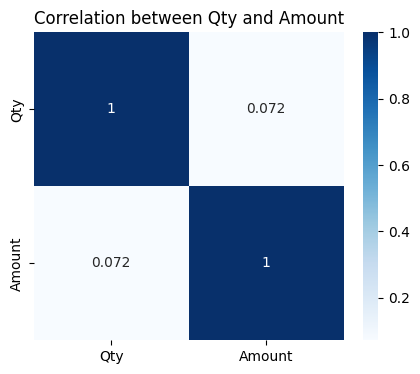

In [7]:
import seaborn as sns


plt.figure(figsize=(5,4))
sns.heatmap(correlation, annot=True, cmap="Blues")
plt.title("Correlation between Qty and Amount")
plt.show()

In [6]:
#hypothesis testing using chi square test
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(df["Category"], df["Status"])

# Perform Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p_value)

# Decision
if p_value < 0.05:
    print("Reject the Null Hypothesis")
    print("Category and Status are associated.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("Category and Status are independent.")

Chi-Square Statistic: 1868.140931442503
P-Value: 0.0
Reject the Null Hypothesis
Category and Status are associated.
